# 03 - Modelagem Supervisionada de Atrasos

Modelos de classificação para prever atraso >15 minutos.

In [12]:
# Imports e carga da amostra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve

data = pd.read_parquet("../data/processed/flights_sample.parquet")
print(data.shape)

(300000, 21)


## 1. Seleção de features e alvo
Usamos apenas informações disponí­veis antes da decolagem para evitar vazamento.

In [14]:
# Seleciona features conhecidas antes da decolagem e o alvo DELAYED
features = ["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT","MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE","IS_WEEKEND"]
X = data[features]
y = data["DELAYED"]

cat_features = ["AIRLINE","ORIGIN_AIRPORT","DESTINATION_AIRPORT"]
num_features = ["MONTH","DAY_OF_WEEK","DEP_HOUR","DISTANCE","IS_WEEKEND"]

## 2. Divisão treino/teste estratificada

In [9]:
# Split estratificado para manter proporcao da classe de atraso
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((240000, 8), (60000, 8))

## 3. Pipeline de pré-processamento
- Imputação para robustez.
- One-hot para categóricas.
- Pass-through para numéricas.

In [15]:
# Pipelines de pre-processamento: imputacao e one-hot para categoricas, mediana para numericas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numerical_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_features),
        ("num", numerical_transformer_scaled, num_features)
    ]
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_features),
        ("num", numerical_transformer, num_features)
    ]
)


## 4. Baseline: Regressão Logí­stica (subamostra)

In [16]:
# Baseline: regressao logistica balanceada (subamostra para velocidade)
log_reg = Pipeline(steps=[
    ("preprocess", preprocessor_lr),
    ("clf", LogisticRegression(max_iter=600, n_jobs=-1, class_weight="balanced"))
])

X_train_lr = X_train.sample(n=100_000, random_state=42)
y_train_lr = y_train.loc[X_train_lr.index]

log_reg.fit(X_train_lr, y_train_lr)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))

              precision    recall  f1-score   support

           0       0.87      0.60      0.71     49323
           1       0.24      0.60      0.35     10677

    accuracy                           0.60     60000
   macro avg       0.56      0.60      0.53     60000
weighted avg       0.76      0.60      0.64     60000

ROC-AUC: 0.6303320026114155


## 5. Modelo principal: Random Forest

In [17]:
# Modelo principal: Random Forest balanceado (tuning leve)
rf = Pipeline(steps=[
    ("preprocess", preprocessor_rf),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


              precision    recall  f1-score   support

           0       0.86      0.79      0.83     49323
           1       0.30      0.41      0.34     10677

    accuracy                           0.73     60000
   macro avg       0.58      0.60      0.59     60000
weighted avg       0.76      0.73      0.74     60000

ROC-AUC: 0.6626535665297374


## 6. Avaliacao e threshold
Relatorios abaixo mostram o desempenho com corte padrao (0.5) e, em seguida, o threshold que maximiza F1 da classe de atraso. O objetivo eh ganhar recall da classe 1 mesmo perdendo um pouco de acuracia.


In [18]:
# Ajuste de threshold maximizando F1 da classe de atraso
prec, rec, thresh = precision_recall_curve(y_test, y_proba_rf)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresh[best_idx]
print(f"Melhor threshold (F1 classe 1): {best_threshold:.3f}")
y_pred_rf_thresh = (y_proba_rf >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_rf_thresh))


Melhor threshold (F1 classe 1): 0.435
              precision    recall  f1-score   support

           0       0.88      0.64      0.74     49323
           1       0.26      0.60      0.36     10677

    accuracy                           0.63     60000
   macro avg       0.57      0.62      0.55     60000
weighted avg       0.77      0.63      0.67     60000



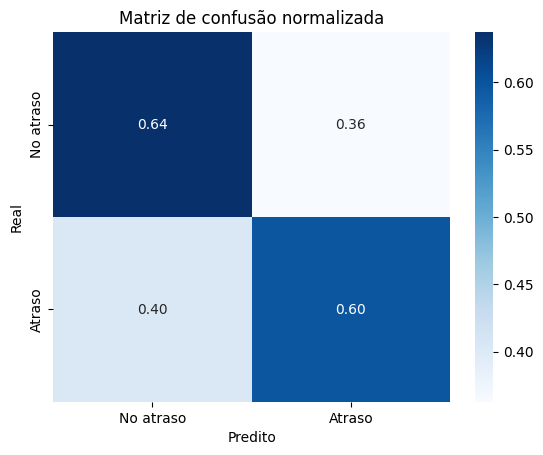

In [8]:
# Matriz de confusao usando predicoes com threshold ajustado
cm = confusion_matrix(y_test, y_pred_rf_thresh, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=["No atraso","Atraso"], yticklabels=["No atraso","Atraso"])
plt.title("Matriz de confusão normalizada")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Conclusoes
- Regressao logistica (class_weight, treino em 100k): ROC-AUC ~0.634; precisao ~0.24 / recall ~0.62 / acc ~0.59; houve aviso de convergencia do solver.
- Random Forest (class_weight, tuning leve): ROC-AUC ~0.663; corte padrao 0.5 entrega precisao ~0.30 / recall ~0.41 / acc ~0.73; threshold otimo ~0.435 sobe recall para ~0.60 com precisao ~0.26 (acc ~0.63).
- Para melhorar: calibrar probabilidades, fazer tuning mais amplo e testar modelos como XGBoost ou mais features de contexto.
